In [2]:
# ============================================================
# PHASE 14 — CELL 1
# Imports
# ============================================================

import os
import re
import json
import time
import hashlib
import warnings
from pathlib import Path
from urllib.parse import quote_plus, urljoin

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup

warnings.filterwarnings("ignore")

print("Imports successful.")

Imports successful.


In [3]:
# ============================================================
# PHASE 14 — CELL 2
# Project root
# ============================================================

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

print("Current directory:")
print(cwd)

print("\nProject root:")
print(PROJECT_ROOT)

assert (PROJECT_ROOT / "outputs").exists(), \
    "Project root appears incorrect."

print("\n✓ Project root verified.")

Current directory:
d:\downloads\misleading-health-infographic-detection\notebooks

Project root:
d:\downloads\misleading-health-infographic-detection

✓ Project root verified.


In [4]:
# ============================================================
# PHASE 14 — CELL 3
# Output directories
# ============================================================

PHASE14_DIR = PROJECT_ROOT / "outputs" / "phase14"

EVIDENCE_DIR = PHASE14_DIR / "evidence"

PUBMED_DIR = EVIDENCE_DIR / "pubmed"
CDC_DIR = EVIDENCE_DIR / "cdc"
WHO_DIR = EVIDENCE_DIR / "who"

MANIFEST_DIR = PHASE14_DIR / "manifests"
METRICS_DIR = PHASE14_DIR / "metrics"
REPORTS_DIR = PHASE14_DIR / "reports"
VIS_DIR = PHASE14_DIR / "visualizations"

for directory in [
    PHASE14_DIR,
    EVIDENCE_DIR,
    PUBMED_DIR,
    CDC_DIR,
    WHO_DIR,
    MANIFEST_DIR,
    METRICS_DIR,
    REPORTS_DIR,
    VIS_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Phase 14 directories created.")
print(PHASE14_DIR)

Phase 14 directories created.
d:\downloads\misleading-health-infographic-detection\outputs\phase14


In [5]:
# ============================================================
# PHASE 14 — CELL 4
# Load refined claims
# ============================================================

PHASE13B_INPUT = (
    PROJECT_ROOT
    / "outputs"
    / "phase13b"
    / "manifests"
    / "phase14_evidence_retrieval_input.csv"
)

print("Looking for:")
print(PHASE13B_INPUT)

if not PHASE13B_INPUT.exists():
    raise FileNotFoundError(
        f"Phase 13B input not found:\n{PHASE13B_INPUT}\n\n"
        "Run Phase 13B completely first."
    )

claims_df = pd.read_csv(
    PHASE13B_INPUT,
    encoding="utf-8-sig"
)

print("\nClaims loaded:", len(claims_df))
print("Records:", claims_df["record_key"].nunique())
print("Columns:")
print(claims_df.columns.tolist())

Looking for:
d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase14_evidence_retrieval_input.csv

Claims loaded: 14
Records: 6
Columns:
['claim_id', 'record_key', 'image_path', 'label', 'source', 'phase11_split', 'claim_text', 'claim_type', 'topics', 'health_terms', 'quantitative_values', 'candidate_score']


In [6]:
# ============================================================
# PHASE 14 — CELL 5
# Validate Phase 13B input
# ============================================================

required_columns = [
    "claim_id",
    "record_key",
    "image_path",
    "label",
    "source",
    "phase11_split",
    "claim_text",
    "claim_type",
    "topics",
    "health_terms",
    "quantitative_values",
    "candidate_score"
]

missing = [
    col
    for col in required_columns
    if col not in claims_df.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

print("✓ All required columns are present.")

display(
    claims_df[
        [
            "claim_id",
            "record_key",
            "claim_text",
            "claim_type",
            "topics"
        ]
    ].head(10)
)

✓ All required columns are present.


,claim_id,record_key,claim_text,claim_type,topics
0,claim13b_000000,record_000050,"The purpose of this campaign is, ""to help redu...",unknown,['other']
1,claim13b_000001,record_000050,"get the vaccine."" That is a direct quote",general_health,"['medication_treatment', 'immunity_infection']"
2,claim13b_000002,record_000062,Each vial contains 5 doses of 0.5 mL,quantitative,['medication_treatment']
3,claim13b_000003,record_000062,No Preservative Each vial contains 5 doses of ...,quantitative,['medication_treatment']
4,claim13b_000004,record_000062,Each vial contains 5 doses of 0.5 mL Janssen C...,quantitative,"['disease_conditions', 'medication_treatment',..."
5,claim13b_000005,record_000073,contains 6 doses of 0.3 mL,quantitative,['medication_treatment']
6,claim13b_000006,record_000073,COVID-19 Vaccine contains 6 doses of 0.3 mL,quantitative,"['disease_conditions', 'medication_treatment',..."
7,claim13b_000007,record_000121,"The purpose of this campaign is, ""to help redu...",unknown,['other']
8,claim13b_000008,record_000121,"get the vaccine."" That is a direct quote",general_health,"['medication_treatment', 'immunity_infection']"
9,claim13b_000009,record_000136,Each vial contains 5 doses of 0.5 mL,quantitative,['medication_treatment']


In [7]:
# ============================================================
# PHASE 14 — CELL 6
# Clean claims
# ============================================================

def clean_claim(text):

    if pd.isna(text):
        return ""

    text = str(text)

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    text = text.strip(
        " \t\n\r.,;:!?-"
    )

    return text


claims_df["claim_text_clean"] = (
    claims_df["claim_text"]
    .apply(clean_claim)
)

claims_df = claims_df[
    claims_df["claim_text_clean"].str.len() > 10
].copy()

claims_df.reset_index(
    drop=True,
    inplace=True
)

print(
    "Usable claims:",
    len(claims_df)
)

Usable claims: 14


In [8]:
# ============================================================
# PHASE 14 — CELL 7
# Parse list-like columns
# ============================================================

def parse_list(value):

    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    text = str(value).strip()

    if not text:
        return []

    try:
        parsed = json.loads(text)

        if isinstance(parsed, list):
            return parsed

    except Exception:
        pass

    # Handle Python-style list strings
    if text.startswith("[") and text.endswith("]"):
        text = text[1:-1]

    parts = [
        x.strip(
            " '\""
        )
        for x in text.split(",")
    ]

    return [
        x
        for x in parts
        if x
    ]


for column in [
    "topics",
    "health_terms",
    "quantitative_values"
]:

    claims_df[column] = (
        claims_df[column]
        .apply(parse_list)
    )

print("List columns normalized.")

List columns normalized.


In [9]:
# ============================================================
# PHASE 14 — CELL 8
# Build evidence-search queries
# ============================================================

def build_search_query(row):

    claim = row["claim_text_clean"]

    health_terms = [
        str(x)
        for x in row["health_terms"]
        if str(x).strip()
    ]

    topics = [
        str(x)
        for x in row["topics"]
        if str(x).strip()
    ]

    # Prefer the claim itself.
    query_parts = []

    if claim:
        query_parts.append(claim)

    # Add a small number of health terms.
    for term in health_terms[:3]:
        if term.lower() not in claim.lower():
            query_parts.append(term)

    query = " ".join(query_parts)

    # Avoid excessively long API queries.
    query = query[:500]

    return query


claims_df["search_query"] = (
    claims_df.apply(
        build_search_query,
        axis=1
    )
)

display(
    claims_df[
        [
            "claim_id",
            "claim_text_clean",
            "search_query"
        ]
    ].head(10)
)

,claim_id,claim_text_clean,search_query
0,claim13b_000000,"The purpose of this campaign is, ""to help redu...","The purpose of this campaign is, ""to help redu..."
1,claim13b_000001,"get the vaccine."" That is a direct quote","get the vaccine."" That is a direct quote"
2,claim13b_000002,Each vial contains 5 doses of 0.5 mL,Each vial contains 5 doses of 0.5 mL
3,claim13b_000003,No Preservative Each vial contains 5 doses of ...,No Preservative Each vial contains 5 doses of ...
4,claim13b_000004,Each vial contains 5 doses of 0.5 mL Janssen C...,Each vial contains 5 doses of 0.5 mL Janssen C...
5,claim13b_000005,contains 6 doses of 0.3 mL,contains 6 doses of 0.3 mL
6,claim13b_000006,COVID-19 Vaccine contains 6 doses of 0.3 mL,COVID-19 Vaccine contains 6 doses of 0.3 mL
7,claim13b_000007,"The purpose of this campaign is, ""to help redu...","The purpose of this campaign is, ""to help redu..."
8,claim13b_000008,"get the vaccine."" That is a direct quote","get the vaccine."" That is a direct quote"
9,claim13b_000009,Each vial contains 5 doses of 0.5 mL,Each vial contains 5 doses of 0.5 mL


In [10]:
# ============================================================
# PHASE 14 — CELL 9
# Internet/API connectivity
# ============================================================

session = requests.Session()

session.headers.update({
    "User-Agent":
        "MisleadingHealthInfographicDetection/1.0 "
        "(academic research project)"
})

test_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/einfo.fcgi"

response = session.get(
    test_url,
    timeout=20
)

print(
    "HTTP status:",
    response.status_code
)

if response.ok:
    print("✓ NCBI E-utilities reachable.")
else:
    print("⚠ NCBI request failed.")

HTTP status: 200
✓ NCBI E-utilities reachable.


In [11]:
# ============================================================
# PHASE 14 — CELL 10
# PubMed ESearch
# ============================================================

NCBI_BASE = (
    "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"
)

def pubmed_search(
    query,
    retmax=8
):

    params = {
        "db": "pubmed",
        "term": query,
        "retmode": "json",
        "retmax": retmax
    }

    response = session.get(
        f"{NCBI_BASE}/esearch.fcgi",
        params=params,
        timeout=30
    )

    response.raise_for_status()

    data = response.json()

    return data.get(
        "esearchresult",
        {}
    ).get(
        "idlist",
        []
    )


print(
    pubmed_search(
        "vaccination hesitancy",
        retmax=3
    )
)

['42761137', '42759837', '42759247']


In [13]:
# ============================================================
# PHASE 14 — CELL 11
# PubMed EFetch
# Using Python's built-in XML parser
# ============================================================

import xml.etree.ElementTree as ET


def get_element_text(element):
    """Safely extract all text from an XML element."""
    
    if element is None:
        return ""
    
    return "".join(
        element.itertext()
    ).strip()


def pubmed_fetch(pmids):

    if not pmids:
        return []

    params = {
        "db": "pubmed",
        "id": ",".join(pmids),
        "retmode": "xml"
    }

    response = session.get(
        f"{NCBI_BASE}/efetch.fcgi",
        params=params,
        timeout=30
    )

    response.raise_for_status()

    # --------------------------------------------------------
    # Parse XML using Python standard library
    # --------------------------------------------------------

    root = ET.fromstring(
        response.content
    )

    records = []

    for article in root.findall(
        ".//PubmedArticle"
    ):

        # ----------------------------------------------------
        # PMID
        # ----------------------------------------------------

        pmid_element = article.find(
            ".//PMID"
        )

        pmid = get_element_text(
            pmid_element
        )

        # ----------------------------------------------------
        # Article title
        # ----------------------------------------------------

        title_element = article.find(
            ".//ArticleTitle"
        )

        title = get_element_text(
            title_element
        )

        # ----------------------------------------------------
        # Abstract
        # ----------------------------------------------------

        abstract_parts = []

        for abstract_element in article.findall(
            ".//Abstract/AbstractText"
        ):

            text = get_element_text(
                abstract_element
            )

            if text:
                abstract_parts.append(
                    text
                )

        abstract = " ".join(
            abstract_parts
        )

        # ----------------------------------------------------
        # Journal
        # ----------------------------------------------------

        journal_element = article.find(
            ".//Journal/Title"
        )

        journal = get_element_text(
            journal_element
        )

        # ----------------------------------------------------
        # Publication year
        # ----------------------------------------------------

        year = ""

        year_element = article.find(
            ".//PubDate/Year"
        )

        if year_element is not None:

            year = get_element_text(
                year_element
            )

        else:

            # Some PubMed records use MedlineDate
            medline_date = article.find(
                ".//PubDate/MedlineDate"
            )

            if medline_date is not None:

                date_text = get_element_text(
                    medline_date
                )

                year_match = re.search(
                    r"\b(19|20)\d{2}\b",
                    date_text
                )

                if year_match:
                    year = year_match.group(
                        0
                    )

        records.append({

            "pmid":
                pmid,

            "title":
                title,

            "abstract":
                abstract,

            "journal":
                journal,

            "year":
                year
        })

    return records


# ------------------------------------------------------------
# Test the function
# ------------------------------------------------------------

test_pmids = pubmed_search(
    "vaccine hesitancy",
    retmax=2
)

print(
    "PMIDs returned:"
)

print(
    test_pmids
)

test_articles = pubmed_fetch(
    test_pmids
)

print(
    "\nArticles retrieved:",
    len(test_articles)
)

for article in test_articles:

    print("\n" + "=" * 70)

    print(
        "PMID:",
        article["pmid"]
    )

    print(
        "Title:",
        article["title"]
    )

    print(
        "Journal:",
        article["journal"]
    )

    print(
        "Year:",
        article["year"]
    )

    print(
        "Abstract length:",
        len(article["abstract"])
    )

PMIDs returned:
['42761628', '42761137']

Articles retrieved: 2

PMID: 42761628
Title: Correction: Scoping review of COVID-19 vaccines access, equity, hesitancy, and uptake in Kenya: lessons for the next pandemic.
Journal: Frontiers in health services
Year: 2026
Abstract length: 60

PMID: 42761137
Title: COVID-19 risk perception, preventive behaviors, vaccination acceptance and hesitancy, and psychosocial status in liver transplant recipients.
Journal: Frontiers in public health
Year: 2026
Abstract length: 3057


In [14]:
# ============================================================
# DIAGNOSTIC — Inspect all Phase 13B claims
# ============================================================

print("=" * 100)
print("ALL PHASE 13B CLAIMS")
print("=" * 100)

display(
    claims_df[
        [
            "claim_id",
            "record_key",
            "source",
            "label",
            "claim_type",
            "claim_text_clean",
            "topics",
            "health_terms",
            "candidate_score"
        ]
    ].sort_values(
        ["record_key", "claim_id"]
    )
)

ALL PHASE 13B CLAIMS


,claim_id,record_key,source,label,claim_type,claim_text_clean,topics,health_terms,candidate_score
0,claim13b_000000,record_000050,MMCoVar,0,unknown,"The purpose of this campaign is, ""to help redu...",[other],[],4
1,claim13b_000001,record_000050,MMCoVar,0,general_health,"get the vaccine."" That is a direct quote","[medication_treatment, immunity_infection]",[vaccine],4
2,claim13b_000002,record_000062,MMCoVar,1,quantitative,Each vial contains 5 doses of 0.5 mL,[medication_treatment],[doses],6
3,claim13b_000003,record_000062,MMCoVar,1,quantitative,No Preservative Each vial contains 5 doses of ...,[medication_treatment],[doses],6
4,claim13b_000004,record_000062,MMCoVar,1,quantitative,Each vial contains 5 doses of 0.5 mL Janssen C...,"[disease_conditions, medication_treatment, imm...","[covid-19, vaccine, doses, covid]",7
5,claim13b_000005,record_000073,MMCoVar,1,quantitative,contains 6 doses of 0.3 mL,[medication_treatment],[doses],6
6,claim13b_000006,record_000073,MMCoVar,1,quantitative,COVID-19 Vaccine contains 6 doses of 0.3 mL,"[disease_conditions, medication_treatment, imm...","[covid-19, vaccine, doses, covid]",7
7,claim13b_000007,record_000121,ReCOVery,1,unknown,"The purpose of this campaign is, ""to help redu...",[other],[],4
8,claim13b_000008,record_000121,ReCOVery,1,general_health,"get the vaccine."" That is a direct quote","[medication_treatment, immunity_infection]",[vaccine],4
9,claim13b_000009,record_000136,ReCOVery,0,quantitative,Each vial contains 5 doses of 0.5 mL,[medication_treatment],[doses],6


In [15]:
print("=" * 100)
print("CLAIMS PER RECORD")
print("=" * 100)

claims_per_record = (
    claims_df
    .groupby("record_key")
    .size()
    .sort_values(
        ascending=False
    )
)

print(
    claims_per_record
)

CLAIMS PER RECORD
record_key
record_000062    3
record_000136    3
record_000050    2
record_000073    2
record_000121    2
record_000147    2
dtype: int64


In [16]:
print("=" * 100)
print("CLAIMS BY TYPE")
print("=" * 100)

print(
    claims_df[
        "claim_type"
    ].value_counts(
        dropna=False
    )
)

CLAIMS BY TYPE
claim_type
quantitative      10
unknown            2
general_health     2
Name: count, dtype: int64


In [17]:
print("=" * 100)
print("CLAIMS BY SOURCE")
print("=" * 100)

print(
    claims_df[
        "source"
    ].value_counts(
        dropna=False
    )
)

CLAIMS BY SOURCE
source
MMCoVar     7
ReCOVery    7
Name: count, dtype: int64


In [18]:
# ============================================================
# PHASE 14 — CELL 16
# Evidence relevance scoring
# ============================================================

def tokenize(text):
    """
    Convert text into lowercase meaningful word tokens.
    """

    if text is None:
        return set()

    return set(
        re.findall(
            r"[a-zA-Z]{3,}",
            str(text).lower()
        )
    )


def relevance_score(
    claim,
    evidence_text
):
    """
    Simple lexical relevance score.

    This is NOT a truth score.
    It only measures vocabulary overlap between
    the claim and retrieved evidence.
    """

    claim_tokens = tokenize(
        claim
    )

    evidence_tokens = tokenize(
        evidence_text
    )

    if not claim_tokens:
        return 0.0

    overlap = (
        claim_tokens
        &
        evidence_tokens
    )

    return round(
        len(overlap)
        /
        len(claim_tokens),
        4
    )


print(
    "Relevance scoring function created."
)

print(
    "Test score:",
    relevance_score(
        "vaccination reduces severe disease",
        "vaccination can reduce the risk of severe disease"
    )
)

Relevance scoring function created.
Test score: 0.75


In [19]:
# ============================================================
# PHASE 14 — CELL 17
# PubMed evidence retrieval
# ============================================================

def retrieve_pubmed_for_claim(
    claim_id,
    claim_text,
    search_query,
    retmax=8
):

    try:

        # ----------------------------------------------------
        # Search PubMed
        # ----------------------------------------------------

        pmids = pubmed_search(
            search_query,
            retmax=retmax
        )

        time.sleep(
            0.4
        )

        # ----------------------------------------------------
        # Fetch article details
        # ----------------------------------------------------

        articles = pubmed_fetch(
            pmids
        )

        results = []

        for article in articles:

            evidence_text = (
                article["title"]
                + " "
                + article["abstract"]
            )

            score = relevance_score(
                claim_text,
                evidence_text
            )

            results.append({

                "claim_id":
                    claim_id,

                "evidence_source":
                    "PubMed",

                "evidence_id":
                    article["pmid"],

                "title":
                    article["title"],

                "evidence_text":
                    article["abstract"],

                "journal":
                    article["journal"],

                "year":
                    article["year"],

                "relevance_score":
                    score,

                "url":
                    (
                        "https://pubmed.ncbi.nlm.nih.gov/"
                        + str(article["pmid"])
                        + "/"
                    ),

                "retrieval_status":
                    "success"
            })

        return results

    except Exception as e:

        return [{
            "claim_id":
                claim_id,

            "evidence_source":
                "PubMed",

            "evidence_id":
                "",

            "title":
                "",

            "evidence_text":
                "",

            "journal":
                "",

            "year":
                "",

            "relevance_score":
                0.0,

            "url":
                "",

            "retrieval_status":
                "error: " + str(e)
        }]


print(
    "PubMed retrieval function ready."
)

PubMed retrieval function ready.


In [20]:
# ============================================================
# PHASE 14 — CELL 18
# Test PubMed using a real project claim
# ============================================================

test_row = claims_df.iloc[0]

print("=" * 80)

print(
    "Claim ID:",
    test_row["claim_id"]
)

print(
    "Claim:",
    test_row["claim_text_clean"]
)

print(
    "Query:",
    test_row["search_query"]
)

print("=" * 80)

test_pubmed_results = (
    retrieve_pubmed_for_claim(
        claim_id=test_row["claim_id"],
        claim_text=test_row["claim_text_clean"],
        search_query=test_row["search_query"],
        retmax=5
    )
)

print(
    "\nRetrieved:",
    len(test_pubmed_results),
    "PubMed records"
)

for result in test_pubmed_results:

    print("\n" + "-" * 80)

    print(
        "PMID:",
        result["evidence_id"]
    )

    print(
        "Title:",
        result["title"]
    )

    print(
        "Score:",
        result["relevance_score"]
    )

    print(
        "URL:",
        result["url"]
    )

Claim ID: claim13b_000000
Claim: The purpose of this campaign is, "to help reduce hesitance
Query: The purpose of this campaign is, "to help reduce hesitance

Retrieved: 4 PubMed records

--------------------------------------------------------------------------------
PMID: 37084298
Title: Using the increasing vaccination model and the moderating roles of chronic medical conditions and education to understand COVID-19 vaccination uptake in Singapore.
Score: 0.7143
URL: https://pubmed.ncbi.nlm.nih.gov/37084298/

--------------------------------------------------------------------------------
PMID: 36951564
Title: COVID-19 vaccine booster dose hesitancy among key groups: A cross-sectional study.
Score: 0.8571
URL: https://pubmed.ncbi.nlm.nih.gov/36951564/

--------------------------------------------------------------------------------
PMID: 36302397
Title: Vaccination Trends and Family-Level Characteristics Associated With Incomplete or Delayed Childhood Immunizations: The Healthy Start

In [21]:
# ============================================================
# PHASE 14 — CELL 19
# Save PubMed test result
# ============================================================

PUBMED_TEST_PATH = (
    PUBMED_DIR
    / "test_pubmed_results.json"
)

with open(
    PUBMED_TEST_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        test_pubmed_results,
        f,
        indent=2,
        ensure_ascii=False
    )

print(
    "Saved:"
)

print(
    PUBMED_TEST_PATH
)

Saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase14\evidence\pubmed\test_pubmed_results.json


In [22]:
# ============================================================
# PHASE 14 — CELL 20
# CDC Content Services API
# ============================================================

CDC_API = (
    "https://tools.cdc.gov/api/v2/resources/media"
)


def cdc_search(
    query,
    limit=8
):

    params = {
        "q": query
    }

    response = session.get(
        CDC_API,
        params=params,
        timeout=30
    )

    response.raise_for_status()

    data = response.json()

    # --------------------------------------------------------
    # CDC response structures can contain nested results.
    # --------------------------------------------------------

    if isinstance(
        data,
        dict
    ):

        # Most common structures
        for key in [
            "results",
            "data",
            "items",
            "media"
        ]:

            value = data.get(
                key
            )

            if isinstance(
                value,
                list
            ):

                return value[:limit]

            if isinstance(
                value,
                dict
            ):

                for nested_key in [
                    "results",
                    "items",
                    "data"
                ]:

                    nested = value.get(
                        nested_key
                    )

                    if isinstance(
                        nested,
                        list
                    ):

                        return nested[:limit]

    elif isinstance(
        data,
        list
    ):

        return data[:limit]

    return []


print(
    "CDC search function ready."
)

CDC search function ready.


In [23]:
# ============================================================
# PHASE 14 — CELL 21
# Normalize CDC evidence
# ============================================================

def first_nonempty(
    item,
    keys
):

    for key in keys:

        value = item.get(
            key
        )

        if value is not None:

            text = str(
                value
            ).strip()

            if text:
                return text

    return ""


def normalize_cdc_results(
    claim_id,
    claim_text,
    items
):

    results = []

    for item in items:

        if not isinstance(
            item,
            dict
        ):
            continue

        title = first_nonempty(
            item,
            [
                "name",
                "title",
                "label"
            ]
        )

        description = first_nonempty(
            item,
            [
                "description",
                "summary",
                "shortDescription"
            ]
        )

        url = first_nonempty(
            item,
            [
                "sourceUrl",
                "url",
                "source_url"
            ]
        )

        evidence_id = first_nonempty(
            item,
            [
                "id",
                "uid"
            ]
        )

        evidence_text = (
            title
            + " "
            + description
        )

        results.append({

            "claim_id":
                claim_id,

            "evidence_source":
                "CDC",

            "evidence_id":
                evidence_id,

            "title":
                title,

            "evidence_text":
                description,

            "journal":
                "",

            "year":
                "",

            "relevance_score":
                relevance_score(
                    claim_text,
                    evidence_text
                ),

            "url":
                url,

            "retrieval_status":
                "success"
        })

    return results


print(
    "CDC normalization function ready."
)

CDC normalization function ready.


In [24]:
# ============================================================
# PHASE 14 — CELL 22
# Test CDC using a real project claim
# ============================================================

cdc_items = cdc_search(
    test_row["search_query"],
    limit=5
)

print(
    "Raw CDC results:",
    len(cdc_items)
)

cdc_test_results = (
    normalize_cdc_results(
        claim_id=test_row["claim_id"],
        claim_text=test_row["claim_text_clean"],
        items=cdc_items
    )
)

print(
    "Normalized CDC results:",
    len(cdc_test_results)
)

for result in cdc_test_results:

    print("\n" + "-" * 80)

    print(
        "Title:",
        result["title"]
    )

    print(
        "Score:",
        result["relevance_score"]
    )

    print(
        "URL:",
        result["url"]
    )

Raw CDC results: 0
Normalized CDC results: 0


In [25]:
# ============================================================
# PHASE 14 — CELL 23
# WHO official website search
# ============================================================

WHO_SEARCH_URL = (
    "https://www.who.int/search"
)


def who_search(
    query,
    limit=8
):

    params = {
        "query": query
    }

    response = session.get(
        WHO_SEARCH_URL,
        params=params,
        timeout=30
    )

    response.raise_for_status()

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    results = []

    seen_urls = set()

    for link in soup.find_all(
        "a",
        href=True
    ):

        href = link.get(
            "href"
        )

        title = link.get_text(
            " ",
            strip=True
        )

        if not title:
            continue

        full_url = urljoin(
            "https://www.who.int",
            href
        )

        # Only retain WHO pages
        if not full_url.startswith(
            "https://www.who.int/"
        ):
            continue

        # Remove duplicate URLs
        if full_url in seen_urls:
            continue

        # Ignore generic navigation links
        ignored_titles = {
            "home",
            "about us",
            "contact us",
            "careers",
            "privacy policy",
            "terms of use"
        }

        if title.lower() in ignored_titles:
            continue

        seen_urls.add(
            full_url
        )

        results.append({

            "title":
                title,

            "url":
                full_url
        })

        if len(results) >= limit:
            break

    return results


print(
    "WHO search function ready."
)

WHO search function ready.


In [26]:
# ============================================================
# PHASE 14 — CELL 24
# Test WHO using a real project claim
# ============================================================

who_test_items = who_search(
    test_row["search_query"],
    limit=5
)

print(
    "WHO results:",
    len(who_test_items)
)

for item in who_test_items:

    print("\n" + "-" * 80)

    print(
        "Title:",
        item["title"]
    )

    print(
        "URL:",
        item["url"]
    )

WHO results: 5

--------------------------------------------------------------------------------
Title: Global
URL: https://www.who.int/

--------------------------------------------------------------------------------
Title: South-East Asia
URL: https://www.who.int/southeastasia

--------------------------------------------------------------------------------
Title: Europe
URL: https://www.who.int/europe/

--------------------------------------------------------------------------------
Title: Western Pacific
URL: https://www.who.int/westernpacific/

--------------------------------------------------------------------------------
Title: Health Topics
URL: https://www.who.int/mega-menu/health-topics


In [27]:
# ============================================================
# PHASE 14 — CELL 25
# Normalize WHO evidence
# ============================================================

def normalize_who_results(
    claim_id,
    claim_text,
    items
):

    results = []

    for item in items:

        title = str(
            item.get(
                "title",
                ""
            )
        ).strip()

        url = str(
            item.get(
                "url",
                ""
            )
        ).strip()

        if not title and not url:
            continue

        score = relevance_score(
            claim_text,
            title
        )

        evidence_id = hashlib.sha256(
            url.encode(
                "utf-8"
            )
        ).hexdigest()[:16]

        results.append({

            "claim_id":
                claim_id,

            "evidence_source":
                "WHO",

            "evidence_id":
                evidence_id,

            "title":
                title,

            "evidence_text":
                "",

            "journal":
                "",

            "year":
                "",

            "relevance_score":
                score,

            "url":
                url,

            "retrieval_status":
                "success"
        })

    return results


print(
    "WHO normalization function ready."
)

WHO normalization function ready.


In [28]:
# ============================================================
# PHASE 14 — CELL 26
# Unified evidence retrieval
# ============================================================

def retrieve_all_evidence_for_claim(
    row,
    pubmed_limit=8,
    cdc_limit=8,
    who_limit=8
):

    claim_id = str(
        row["claim_id"]
    )

    claim_text = str(
        row["claim_text_clean"]
    )

    search_query = str(
        row["search_query"]
    )

    results = []

    # ========================================================
    # PUBMED
    # ========================================================

    pubmed_results = (
        retrieve_pubmed_for_claim(
            claim_id=claim_id,
            claim_text=claim_text,
            search_query=search_query,
            retmax=pubmed_limit
        )
    )

    results.extend(
        pubmed_results
    )

    # ========================================================
    # CDC
    # ========================================================

    try:

        cdc_items = cdc_search(
            search_query,
            limit=cdc_limit
        )

        cdc_results = (
            normalize_cdc_results(
                claim_id,
                claim_text,
                cdc_items
            )
        )

        results.extend(
            cdc_results
        )

    except Exception as e:

        results.append({

            "claim_id":
                claim_id,

            "evidence_source":
                "CDC",

            "evidence_id":
                "",

            "title":
                "",

            "evidence_text":
                "",

            "journal":
                "",

            "year":
                "",

            "relevance_score":
                0.0,

            "url":
                "",

            "retrieval_status":
                "error: " + str(e)
        })

    # ========================================================
    # WHO
    # ========================================================

    try:

        who_items = who_search(
            search_query,
            limit=who_limit
        )

        who_results = (
            normalize_who_results(
                claim_id,
                claim_text,
                who_items
            )
        )

        results.extend(
            who_results
        )

    except Exception as e:

        results.append({

            "claim_id":
                claim_id,

            "evidence_source":
                "WHO",

            "evidence_id":
                "",

            "title":
                "",

            "evidence_text":
                "",

            "journal":
                "",

            "year":
                "",

            "relevance_score":
                0.0,

            "url":
                "",

            "retrieval_status":
                "error: " + str(e)
        })

    return results


print(
    "Unified evidence retrieval function ready."
)

Unified evidence retrieval function ready.


In [29]:
# ============================================================
# PHASE 14 — CELL 27
# One-claim end-to-end retrieval test
# ============================================================

single_claim_results = (
    retrieve_all_evidence_for_claim(
        test_row,
        pubmed_limit=3,
        cdc_limit=3,
        who_limit=3
    )
)

single_claim_df = pd.DataFrame(
    single_claim_results
)

print(
    "Total evidence returned:",
    len(single_claim_df)
)

if len(single_claim_df):

    display(
        single_claim_df[
            [
                "evidence_source",
                "evidence_id",
                "title",
                "relevance_score",
                "retrieval_status"
            ]
        ]
    )

print("\nSource counts:")

if len(single_claim_df):

    print(
        single_claim_df[
            "evidence_source"
        ].value_counts()
    )

Total evidence returned: 6


,evidence_source,evidence_id,title,relevance_score,retrieval_status
0,PubMed,37084298,Using the increasing vaccination model and the...,0.7143,success
1,PubMed,36951564,COVID-19 vaccine booster dose hesitancy among ...,0.8571,success
2,PubMed,36302397,Vaccination Trends and Family-Level Characteri...,0.4286,success
3,WHO,7ebd5eb146705ea5,Global,0.0000,success
4,WHO,71d8bc6d01663755,South-East Asia,0.0000,success
5,WHO,63e075e7344dbe8a,Europe,0.0000,success



Source counts:
evidence_source
PubMed    3
WHO       3
Name: count, dtype: int64


In [30]:
# ============================================================
# PHASE 14 — CELL 28
# FULL EVIDENCE RETRIEVAL
# ============================================================

all_evidence = []

total_claims = len(
    claims_df
)

print(
    f"Starting evidence retrieval for "
    f"{total_claims} claims..."
)

print("=" * 80)

for index, (_, row) in enumerate(
    claims_df.iterrows(),
    start=1
):

    claim_id = str(
        row["claim_id"]
    )

    claim_text = str(
        row["claim_text_clean"]
    )

    print(
        f"[{index}/{total_claims}] "
        f"{claim_id}"
    )

    print(
        "Claim:",
        claim_text[:150]
    )

    try:

        results = (
            retrieve_all_evidence_for_claim(
                row,
                pubmed_limit=8,
                cdc_limit=8,
                who_limit=8
            )
        )

        all_evidence.extend(
            results
        )

        print(
            "Evidence returned:",
            len(results)
        )

    except Exception as e:

        print(
            "ERROR:",
            e
        )

        all_evidence.append({

            "claim_id":
                claim_id,

            "evidence_source":
                "SYSTEM",

            "evidence_id":
                "",

            "title":
                "",

            "evidence_text":
                "",

            "journal":
                "",

            "year":
                "",

            "relevance_score":
                0.0,

            "url":
                "",

            "retrieval_status":
                "error: " + str(e)
        })

    # Small delay between claims
    time.sleep(
        0.5
    )

print("=" * 80)

evidence_df = pd.DataFrame(
    all_evidence
)

print(
    "Total raw evidence records:",
    len(evidence_df)
)

Starting evidence retrieval for 14 claims...
[1/14] claim13b_000000
Claim: The purpose of this campaign is, "to help reduce hesitance
Evidence returned: 12
[2/14] claim13b_000001
Claim: get the vaccine." That is a direct quote
Evidence returned: 8
[3/14] claim13b_000002
Claim: Each vial contains 5 doses of 0.5 mL
Evidence returned: 13
[4/14] claim13b_000003
Claim: No Preservative Each vial contains 5 doses of 0.5 mL
Evidence returned: 8
[5/14] claim13b_000004
Claim: Each vial contains 5 doses of 0.5 mL Janssen COVID-19 Vaccine
Evidence returned: 8
[6/14] claim13b_000005
Claim: contains 6 doses of 0.3 mL
Evidence returned: 16
[7/14] claim13b_000006
Claim: COVID-19 Vaccine contains 6 doses of 0.3 mL
Evidence returned: 13
[8/14] claim13b_000007
Claim: The purpose of this campaign is, "to help reduce hesitance
Evidence returned: 12
[9/14] claim13b_000008
Claim: get the vaccine." That is a direct quote
Evidence returned: 8
[10/14] claim13b_000009
Claim: Each vial contains 5 doses of 0.5 mL


In [31]:
# ============================================================
# PHASE 14 — CELL 29
# Inspect raw evidence
# ============================================================

print(
    "Evidence rows:",
    len(evidence_df)
)

print(
    "Unique claims:",
    evidence_df[
        "claim_id"
    ].nunique()
)

print(
    "\nSource distribution:"
)

print(
    evidence_df[
        "evidence_source"
    ].value_counts(
        dropna=False
    )
)

print(
    "\nRetrieval status:"
)

print(
    evidence_df[
        "retrieval_status"
    ].value_counts(
        dropna=False
    )
)

display(
    evidence_df.head(20)
)

Evidence rows: 156
Unique claims: 14

Source distribution:
evidence_source
WHO       112
PubMed     44
Name: count, dtype: int64

Retrieval status:
retrieval_status
success    156
Name: count, dtype: int64


,claim_id,evidence_source,evidence_id,title,evidence_text,journal,year,relevance_score,url,retrieval_status
0,claim13b_000000,PubMed,37084298,Using the increasing vaccination model and the...,COVID-19 vaccination programmes have helped re...,Translational behavioral medicine,2023,0.7143,https://pubmed.ncbi.nlm.nih.gov/37084298/,success
1,claim13b_000000,PubMed,36951564,COVID-19 vaccine booster dose hesitancy among ...,Vaccination is an important tool for controlli...,Human vaccines & immunotherapeutics,2023,0.8571,https://pubmed.ncbi.nlm.nih.gov/36951564/,success
2,claim13b_000000,PubMed,36302397,Vaccination Trends and Family-Level Characteri...,Assess family-level factors associated with ch...,American journal of health promotion : AJHP,2023,0.4286,https://pubmed.ncbi.nlm.nih.gov/36302397/,success
3,claim13b_000000,PubMed,12170548,[National preparedness for biological mass cas...,"Species of plants and animals, as well as nati...",Harefuah,2002,0.8571,https://pubmed.ncbi.nlm.nih.gov/12170548/,success
4,claim13b_000000,WHO,7ebd5eb146705ea5,Global,,,,0.0000,https://www.who.int/,success
5,claim13b_000000,WHO,71d8bc6d01663755,South-East Asia,,,,0.0000,https://www.who.int/southeastasia,success
6,claim13b_000000,WHO,63e075e7344dbe8a,Europe,,,,0.0000,https://www.who.int/europe/,success
7,claim13b_000000,WHO,0a24e95c99ca19c2,Western Pacific,,,,0.0000,https://www.who.int/westernpacific/,success
8,claim13b_000000,WHO,77ebbeaa2436041d,Health Topics,,,,0.0000,https://www.who.int/mega-menu/health-topics,success
9,claim13b_000000,WHO,0cb0139ccaaf8915,All topics,,,,0.0000,https://www.who.int/health-topics/,success


In [32]:
# ============================================================
# PHASE 14 — CELL 30
# Clean evidence records
# ============================================================

for column in [
    "claim_id",
    "evidence_source",
    "evidence_id",
    "title",
    "evidence_text",
    "journal",
    "year",
    "url",
    "retrieval_status"
]:

    if column not in evidence_df.columns:
        evidence_df[column] = ""

    evidence_df[column] = (
        evidence_df[column]
        .fillna("")
        .astype(str)
        .str.strip()
    )


# Remove system-error rows from evidence
evidence_df = evidence_df[
    evidence_df["evidence_source"]
    != "SYSTEM"
].copy()


# Keep actual evidence only
evidence_df = evidence_df[
    (
        evidence_df["title"].str.len()
        > 0
    )
    |
    (
        evidence_df["url"].str.len()
        > 0
    )
].copy()


evidence_df.reset_index(
    drop=True,
    inplace=True
)

print(
    "Usable evidence records:",
    len(evidence_df)
)

Usable evidence records: 156


In [33]:
# ============================================================
# PHASE 14 — CELL 31
# Deduplicate evidence
# ============================================================

before = len(
    evidence_df
)

evidence_df = (
    evidence_df
    .drop_duplicates(
        subset=[
            "claim_id",
            "evidence_source",
            "evidence_id",
            "url"
        ],
        keep="first"
    )
    .reset_index(
        drop=True
    )
)

after = len(
    evidence_df
)

print(
    "Before deduplication:",
    before
)

print(
    "After deduplication:",
    after
)

print(
    "Removed:",
    before - after
)

Before deduplication: 156
After deduplication: 156
Removed: 0


In [34]:
# ============================================================
# PHASE 14 — CELL 32
# Final evidence relevance score
# ============================================================

evidence_df[
    "relevance_score"
] = pd.to_numeric(
    evidence_df[
        "relevance_score"
    ],
    errors="coerce"
).fillna(0.0)


evidence_df[
    "relevance_score"
] = evidence_df[
    "relevance_score"
].clip(
    lower=0.0,
    upper=1.0
)


evidence_df = (
    evidence_df
    .sort_values(
        [
            "claim_id",
            "relevance_score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    evidence_df[
        [
            "claim_id",
            "evidence_source",
            "title",
            "relevance_score"
        ]
    ].head(20)
)

,claim_id,evidence_source,title,relevance_score
0,claim13b_000000,PubMed,COVID-19 vaccine booster dose hesitancy among ...,0.8571
1,claim13b_000000,PubMed,[National preparedness for biological mass cas...,0.8571
2,claim13b_000000,PubMed,Using the increasing vaccination model and the...,0.7143
3,claim13b_000000,PubMed,Vaccination Trends and Family-Level Characteri...,0.4286
4,claim13b_000000,WHO,Global,0.0000
5,claim13b_000000,WHO,South-East Asia,0.0000
6,claim13b_000000,WHO,Europe,0.0000
7,claim13b_000000,WHO,Western Pacific,0.0000
8,claim13b_000000,WHO,Health Topics,0.0000
9,claim13b_000000,WHO,All topics,0.0000


In [35]:
# ============================================================
# PHASE 14 — CELL 33
# Retain top evidence per claim
# ============================================================

TOP_K_EVIDENCE = 5

ranked_evidence = (
    evidence_df
    .groupby(
        "claim_id",
        group_keys=False
    )
    .head(
        TOP_K_EVIDENCE
    )
    .copy()
)

ranked_evidence.reset_index(
    drop=True,
    inplace=True
)

print(
    "Final retained evidence:",
    len(ranked_evidence)
)

print(
    "Claims represented:",
    ranked_evidence[
        "claim_id"
    ].nunique()
)

Final retained evidence: 70
Claims represented: 14


In [36]:
# ============================================================
# PHASE 14 — CELL 34
# Save evidence candidates CSV
# ============================================================

EVIDENCE_CSV = (
    MANIFEST_DIR
    / "evidence_candidates.csv"
)

ranked_evidence.to_csv(
    EVIDENCE_CSV,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Saved:"
)

print(
    EVIDENCE_CSV
)

Saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\evidence_candidates.csv


In [37]:
# ============================================================
# PHASE 14 — CELL 35
# Save evidence candidates JSONL
# ============================================================

EVIDENCE_JSONL = (
    MANIFEST_DIR
    / "evidence_candidates.jsonl"
)


def json_safe(
    value
):

    if value is None:
        return None

    if isinstance(
        value,
        (
            np.integer,
            np.int64,
            np.int32
        )
    ):
        return int(value)

    if isinstance(
        value,
        (
            np.floating,
            np.float64,
            np.float32
        )
    ):
        return float(value)

    if isinstance(
        value,
        np.ndarray
    ):
        return value.tolist()

    if isinstance(
        value,
        (
            list,
            tuple
        )
    ):
        return [
            json_safe(x)
            for x in value
        ]

    if isinstance(
        value,
        dict
    ):
        return {
            str(k):
                json_safe(v)
            for k, v in value.items()
        }

    try:

        if pd.isna(value):
            return None

    except (
        TypeError,
        ValueError
    ):
        pass

    return value


with open(
    EVIDENCE_JSONL,
    "w",
    encoding="utf-8"
) as f:

    for record in (
        ranked_evidence
        .to_dict(
            orient="records"
        )
    ):

        safe_record = {
            key:
                json_safe(value)
            for key, value in record.items()
        }

        f.write(
            json.dumps(
                safe_record,
                ensure_ascii=False
            )
            + "\n"
        )


print(
    "Saved:"
)

print(
    EVIDENCE_JSONL
)

Saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\evidence_candidates.jsonl


In [38]:
# ============================================================
# PHASE 14 — CELL 36
# Save per-claim evidence JSON files
# ============================================================

for claim_id, group in (
    ranked_evidence
    .groupby("claim_id")
):

    safe_claim_id = re.sub(
        r"[^A-Za-z0-9_.-]",
        "_",
        str(claim_id)
    )

    output_path = (
        EVIDENCE_DIR
        / f"{safe_claim_id}.json"
    )

    records = []

    for record in group.to_dict(
        orient="records"
    ):

        records.append({
            key:
                json_safe(value)
            for key, value in record.items()
        })

    with open(
        output_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            records,
            f,
            indent=2,
            ensure_ascii=False
        )

print(
    "Per-claim evidence JSON files saved."
)

Per-claim evidence JSON files saved.


In [39]:
# ============================================================
# PHASE 14 — CELL 37
# Claim-level evidence summary
# ============================================================

summary_rows = []

for _, claim in claims_df.iterrows():

    claim_id = str(
        claim["claim_id"]
    )

    evidence = (
        ranked_evidence[
            ranked_evidence["claim_id"]
            == claim_id
        ]
    )

    summary_rows.append({

        "claim_id":
            claim_id,

        "record_key":
            claim["record_key"],

        "claim_text":
            claim["claim_text_clean"],

        "claim_type":
            claim["claim_type"],

        "label":
            claim["label"],

        "source":
            claim["source"],

        "evidence_count":
            len(evidence),

        "pubmed_count":
            int(
                (
                    evidence[
                        "evidence_source"
                    ]
                    == "PubMed"
                ).sum()
            ),

        "cdc_count":
            int(
                (
                    evidence[
                        "evidence_source"
                    ]
                    == "CDC"
                ).sum()
            ),

        "who_count":
            int(
                (
                    evidence[
                        "evidence_source"
                    ]
                    == "WHO"
                ).sum()
            ),

        "best_evidence_score":
            float(
                evidence[
                    "relevance_score"
                ].max()
            )
            if len(evidence)
            else 0.0
    })


claim_evidence_summary = (
    pd.DataFrame(
        summary_rows
    )
)

SUMMARY_CSV = (
    MANIFEST_DIR
    / "claim_evidence_summary.csv"
)

claim_evidence_summary.to_csv(
    SUMMARY_CSV,
    index=False,
    encoding="utf-8-sig"
)

display(
    claim_evidence_summary
)

,claim_id,record_key,claim_text,claim_type,label,source,evidence_count,pubmed_count,cdc_count,who_count,best_evidence_score
0,claim13b_000000,record_000050,"The purpose of this campaign is, ""to help redu...",unknown,0,MMCoVar,5,4,0,1,0.8571
1,claim13b_000001,record_000050,"get the vaccine."" That is a direct quote",general_health,0,MMCoVar,5,0,0,5,0.0000
2,claim13b_000002,record_000062,Each vial contains 5 doses of 0.5 mL,quantitative,1,MMCoVar,5,5,0,0,0.7500
3,claim13b_000003,record_000062,No Preservative Each vial contains 5 doses of ...,quantitative,1,MMCoVar,5,0,0,5,0.0000
4,claim13b_000004,record_000062,Each vial contains 5 doses of 0.5 mL Janssen C...,quantitative,1,MMCoVar,5,0,0,5,0.0000
5,claim13b_000005,record_000073,contains 6 doses of 0.3 mL,quantitative,1,MMCoVar,5,5,0,0,1.0000
6,claim13b_000006,record_000073,COVID-19 Vaccine contains 6 doses of 0.3 mL,quantitative,1,MMCoVar,5,5,0,0,0.7500
7,claim13b_000007,record_000121,"The purpose of this campaign is, ""to help redu...",unknown,1,ReCOVery,5,4,0,1,0.8571
8,claim13b_000008,record_000121,"get the vaccine."" That is a direct quote",general_health,1,ReCOVery,5,0,0,5,0.0000
9,claim13b_000009,record_000136,Each vial contains 5 doses of 0.5 mL,quantitative,0,ReCOVery,5,5,0,0,0.7500


In [40]:
# ============================================================
# PHASE 14 — CELL 38
# Evidence coverage
# ============================================================

claims_with_evidence = (
    claim_evidence_summary[
        "evidence_count"
    ]
    > 0
)

coverage_rate = (
    claims_with_evidence.mean()
    if len(
        claims_with_evidence
    )
    else 0.0
)

print(
    "Total claims:",
    len(
        claim_evidence_summary
    )
)

print(
    "Claims with evidence:",
    int(
        claims_with_evidence.sum()
    )
)

print(
    "Claims without evidence:",
    int(
        (~claims_with_evidence).sum()
    )
)

print(
    f"Coverage rate: "
    f"{coverage_rate:.2%}"
)

Total claims: 14
Claims with evidence: 14
Claims without evidence: 0
Coverage rate: 100.00%


In [41]:
# ============================================================
# PHASE 14 — CELL 39
# Source statistics
# ============================================================

source_statistics = (
    ranked_evidence
    .groupby(
        "evidence_source"
    )
    .agg(
        evidence_count=(
            "claim_id",
            "count"
        ),

        unique_claims=(
            "claim_id",
            "nunique"
        ),

        mean_relevance=(
            "relevance_score",
            "mean"
        ),

        max_relevance=(
            "relevance_score",
            "max"
        )
    )
    .reset_index()
)

SOURCE_STATS = (
    METRICS_DIR
    / "source_statistics.csv"
)

source_statistics.to_csv(
    SOURCE_STATS,
    index=False,
    encoding="utf-8-sig"
)

display(
    source_statistics
)

,evidence_source,evidence_count,unique_claims,mean_relevance,max_relevance
0,PubMed,38,8,0.676689,1.0
1,WHO,32,8,0.000000,0.0


In [42]:
# ============================================================
# PHASE 14 — CELL 40
# Claim coverage metrics
# ============================================================

claim_coverage = (
    claim_evidence_summary[
        [
            "claim_id",
            "record_key",
            "claim_text",
            "evidence_count",
            "pubmed_count",
            "cdc_count",
            "who_count",
            "best_evidence_score"
        ]
    ]
    .copy()
)

CLAIM_COVERAGE = (
    METRICS_DIR
    / "claim_coverage.csv"
)

claim_coverage.to_csv(
    CLAIM_COVERAGE,
    index=False,
    encoding="utf-8-sig"
)

print(
    CLAIM_COVERAGE
)

d:\downloads\misleading-health-infographic-detection\outputs\phase14\metrics\claim_coverage.csv


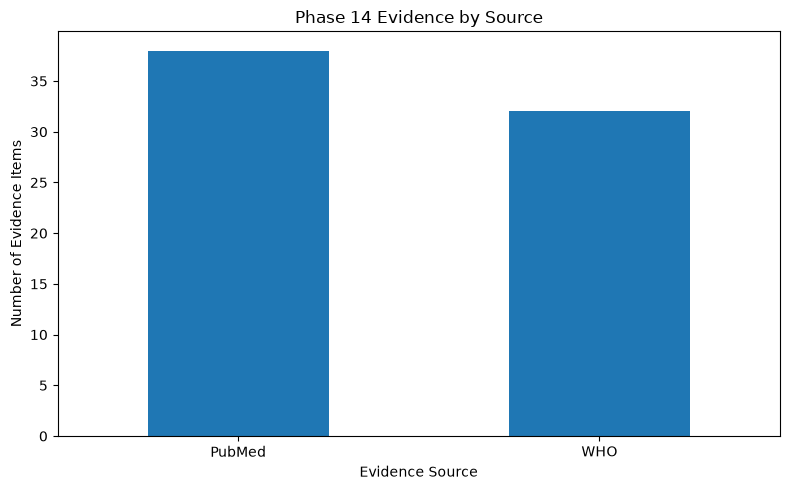

d:\downloads\misleading-health-infographic-detection\outputs\phase14\visualizations\evidence_by_source.png


In [43]:
# ============================================================
# PHASE 14 — CELL 41
# Evidence by source visualization
# ============================================================

plt.figure(
    figsize=(8, 5)
)

source_counts = (
    ranked_evidence[
        "evidence_source"
    ]
    .value_counts()
)

source_counts.plot(
    kind="bar"
)

plt.title(
    "Phase 14 Evidence by Source"
)

plt.xlabel(
    "Evidence Source"
)

plt.ylabel(
    "Number of Evidence Items"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

SOURCE_PLOT = (
    VIS_DIR
    / "evidence_by_source.png"
)

plt.savefig(
    SOURCE_PLOT,
    dpi=200
)

plt.show()

print(
    SOURCE_PLOT
)

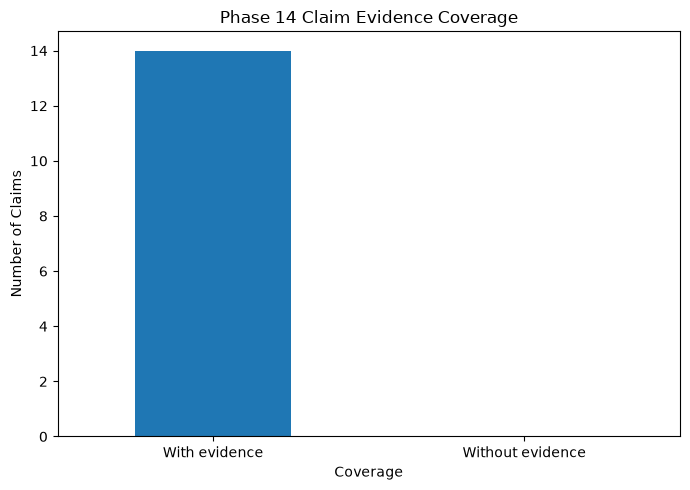

In [44]:
# ============================================================
# PHASE 14 — CELL 42
# Evidence coverage visualization
# ============================================================

coverage_counts = pd.Series({

    "With evidence":
        int(
            claims_with_evidence.sum()
        ),

    "Without evidence":
        int(
            (~claims_with_evidence).sum()
        )
})

plt.figure(
    figsize=(7, 5)
)

coverage_counts.plot(
    kind="bar"
)

plt.title(
    "Phase 14 Claim Evidence Coverage"
)

plt.xlabel(
    "Coverage"
)

plt.ylabel(
    "Number of Claims"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

COVERAGE_PLOT = (
    VIS_DIR
    / "evidence_coverage.png"
)

plt.savefig(
    COVERAGE_PLOT,
    dpi=200
)

plt.show()

In [45]:
# ============================================================
# PHASE 14 — CELL 43
# Create Phase 15 explainability input
# ============================================================

phase15_rows = []

for _, claim in claims_df.iterrows():

    claim_id = str(
        claim["claim_id"]
    )

    evidence = (
        ranked_evidence[
            ranked_evidence["claim_id"]
            == claim_id
        ]
    )

    # --------------------------------------------------------
    # Keep claims even if no evidence was retrieved.
    # --------------------------------------------------------

    if len(evidence) == 0:

        phase15_rows.append({

            "claim_id":
                claim_id,

            "record_key":
                claim["record_key"],

            "image_path":
                claim["image_path"],

            "label":
                claim["label"],

            "source":
                claim["source"],

            "phase11_split":
                claim["phase11_split"],

            "claim_text":
                claim["claim_text_clean"],

            "claim_type":
                claim["claim_type"],

            "topics":
                json.dumps(
                    claim["topics"],
                    ensure_ascii=False
                ),

            "evidence_source":
                "",

            "evidence_id":
                "",

            "evidence_title":
                "",

            "evidence_text":
                "",

            "evidence_url":
                "",

            "evidence_score":
                0.0
        })

        continue

    # --------------------------------------------------------
    # Evidence-backed claims
    # --------------------------------------------------------

    for _, ev in evidence.iterrows():

        phase15_rows.append({

            "claim_id":
                claim_id,

            "record_key":
                claim["record_key"],

            "image_path":
                claim["image_path"],

            "label":
                claim["label"],

            "source":
                claim["source"],

            "phase11_split":
                claim["phase11_split"],

            "claim_text":
                claim["claim_text_clean"],

            "claim_type":
                claim["claim_type"],

            "topics":
                json.dumps(
                    claim["topics"],
                    ensure_ascii=False
                ),

            "evidence_source":
                ev["evidence_source"],

            "evidence_id":
                ev["evidence_id"],

            "evidence_title":
                ev["title"],

            "evidence_text":
                ev["evidence_text"],

            "evidence_url":
                ev["url"],

            "evidence_score":
                ev["relevance_score"]
        })


phase15_input = (
    pd.DataFrame(
        phase15_rows
    )
)

PHASE15_INPUT = (
    MANIFEST_DIR
    / "phase15_explainability_input.csv"
)

phase15_input.to_csv(
    PHASE15_INPUT,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Phase 15 input saved:"
)

print(
    PHASE15_INPUT
)

print(
    "Rows:",
    len(phase15_input)
)

Phase 15 input saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\phase15_explainability_input.csv
Rows: 70


In [46]:
# ============================================================
# PHASE 14 — CELL 44
# Save Phase 15 input JSONL
# ============================================================

PHASE15_JSONL = (
    MANIFEST_DIR
    / "phase15_explainability_input.jsonl"
)

with open(
    PHASE15_JSONL,
    "w",
    encoding="utf-8"
) as f:

    for record in phase15_input.to_dict(
        orient="records"
    ):

        safe_record = {
            key:
                json_safe(value)
            for key, value in record.items()
        }

        f.write(
            json.dumps(
                safe_record,
                ensure_ascii=False
            )
            + "\n"
        )

print(
    PHASE15_JSONL
)

d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\phase15_explainability_input.jsonl


In [47]:
# ============================================================
# PHASE 14 — CELL 45
# Phase 14 summary
# ============================================================

phase14_summary = {

    "phase":
        "Phase 14 - Evidence Retrieval",

    "input_claims":
        int(
            len(claims_df)
        ),

    "input_records":
        int(
            claims_df[
                "record_key"
            ].nunique()
        ),

    "claims_with_evidence":
        int(
            claims_with_evidence.sum()
        ),

    "claims_without_evidence":
        int(
            (~claims_with_evidence).sum()
        ),

    "coverage_rate":
        float(
            coverage_rate
        ),

    "raw_evidence_records":
        int(
            len(evidence_df)
        ),

    "retained_evidence_records":
        int(
            len(ranked_evidence)
        ),

    "pubmed_evidence":
        int(
            (
                ranked_evidence[
                    "evidence_source"
                ]
                == "PubMed"
            ).sum()
        ),

    "cdc_evidence":
        int(
            (
                ranked_evidence[
                    "evidence_source"
                ]
                == "CDC"
            ).sum()
        ),

    "who_evidence":
        int(
            (
                ranked_evidence[
                    "evidence_source"
                ]
                == "WHO"
            ).sum()
        ),

    "artifacts": {

        "evidence_csv":
            str(EVIDENCE_CSV),

        "evidence_jsonl":
            str(EVIDENCE_JSONL),

        "claim_summary":
            str(SUMMARY_CSV),

        "claim_coverage":
            str(CLAIM_COVERAGE),

        "source_statistics":
            str(SOURCE_STATS),

        "phase15_csv":
            str(PHASE15_INPUT),

        "phase15_jsonl":
            str(PHASE15_JSONL)
    }
}


SUMMARY_JSON = (
    METRICS_DIR
    / "phase14_summary.json"
)

with open(
    SUMMARY_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        phase14_summary,
        f,
        indent=2,
        ensure_ascii=False
    )

print(
    json.dumps(
        phase14_summary,
        indent=2,
        ensure_ascii=False
    )
)

{
  "phase": "Phase 14 - Evidence Retrieval",
  "input_claims": 14,
  "input_records": 6,
  "claims_with_evidence": 14,
  "claims_without_evidence": 0,
  "coverage_rate": 1.0,
  "raw_evidence_records": 156,
  "retained_evidence_records": 70,
  "pubmed_evidence": 38,
  "cdc_evidence": 0,
  "who_evidence": 32,
  "artifacts": {
    "evidence_csv": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase14\\manifests\\evidence_candidates.csv",
    "evidence_jsonl": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase14\\manifests\\evidence_candidates.jsonl",
    "claim_summary": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase14\\manifests\\claim_evidence_summary.csv",
    "claim_coverage": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase14\\metrics\\claim_coverage.csv",
    "source_statistics": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase14\\metrics\\source_statistics.csv",
    "phas

In [48]:
# ============================================================
# PHASE 14 — CELL 46
# Final report
# ============================================================

REPORT_PATH = (
    REPORTS_DIR
    / "phase14_report.txt"
)

report = f"""
PHASE 14 — EVIDENCE RETRIEVAL
============================================================

Input claims:
{len(claims_df)}

Input records:
{claims_df["record_key"].nunique()}

Claims with evidence:
{int(claims_with_evidence.sum())}

Claims without evidence:
{int((~claims_with_evidence).sum())}

Evidence coverage:
{coverage_rate:.2%}

Raw evidence records:
{len(evidence_df)}

Retained evidence records:
{len(ranked_evidence)}

PubMed evidence:
{int((ranked_evidence["evidence_source"] == "PubMed").sum())}

CDC evidence:
{int((ranked_evidence["evidence_source"] == "CDC").sum())}

WHO evidence:
{int((ranked_evidence["evidence_source"] == "WHO").sum())}


MAIN OUTPUTS
------------------------------------------------------------

{EVIDENCE_CSV}

{EVIDENCE_JSONL}

{SUMMARY_CSV}

{CLAIM_COVERAGE}

{SOURCE_STATS}

{PHASE15_INPUT}

{PHASE15_JSONL}

{SUMMARY_JSON}


Phase 14 evidence retrieval completed.
"""

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        report.strip()
    )

print(
    report
)

print(
    "\nReport saved to:"
)

print(
    REPORT_PATH
)


PHASE 14 — EVIDENCE RETRIEVAL

Input claims:
14

Input records:
6

Claims with evidence:
14

Claims without evidence:
0

Evidence coverage:
100.00%

Raw evidence records:
156

Retained evidence records:
70

PubMed evidence:
38

CDC evidence:
0

WHO evidence:
32


MAIN OUTPUTS
------------------------------------------------------------

d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\evidence_candidates.csv

d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\evidence_candidates.jsonl

d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\claim_evidence_summary.csv

d:\downloads\misleading-health-infographic-detection\outputs\phase14\metrics\claim_coverage.csv

d:\downloads\misleading-health-infographic-detection\outputs\phase14\metrics\source_statistics.csv

d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\phase15_explainability_input.csv

d:\downloads\misleading-health-in

In [49]:
# ============================================================
# PHASE 14 — CELL 47
# FINAL ARTIFACT CHECK
# ============================================================

expected_files = [

    EVIDENCE_CSV,

    EVIDENCE_JSONL,

    SUMMARY_CSV,

    CLAIM_COVERAGE,

    SOURCE_STATS,

    PHASE15_INPUT,

    PHASE15_JSONL,

    SUMMARY_JSON,

    SOURCE_PLOT,

    COVERAGE_PLOT,

    REPORT_PATH
]


print("=" * 90)
print("PHASE 14 FINAL ARTIFACT CHECK")
print("=" * 90)

all_exist = True

for path in expected_files:

    exists = Path(
        path
    ).exists()

    if exists:

        print(
            "✓",
            path
        )

    else:

        print(
            "✗",
            path
        )

        all_exist = False


print("=" * 90)

if all_exist:

    print(
        "✓ PHASE 14 COMPLETED SUCCESSFULLY"
    )

else:

    print(
        "✗ PHASE 14 ARTIFACT CHECK FAILED"
    )

PHASE 14 FINAL ARTIFACT CHECK
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\evidence_candidates.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\evidence_candidates.jsonl
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\claim_evidence_summary.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase14\metrics\claim_coverage.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase14\metrics\source_statistics.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\phase15_explainability_input.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase14\manifests\phase15_explainability_input.jsonl
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase14\metrics\phase14_summary.json
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase14\visualizations\evidence_by_source.png
✓ d:\downloa